# BirdCLEF+ 2026: Acoustic Species Identification in the Pantanal

![](https://i.ibb.co/PsRD0FLf/IMG-20260314-WA0088.jpg)

---

**Table of Contents**

1. [Setup and Configuration](#1)
2. [Data Inventory](#2)
3. [Exploratory Data Analysis](#3)
4. [Audio Visualizations](#4)
5. [Labeled Soundscapes Deep-Dive](#5)
6. [Model Architecture and Training](#6)
7. [Inference Pipeline](#7)
8. [Results and Next Steps](#8)

<a id="1"></a>
## 1. Setup and Configuration

The Pantanal is one of the largest tropical wetlands on the planet -- over 150,000 square kilometers of seasonally flooded grasslands, savannas, and forests spanning Brazil, Bolivia, and Paraguay. It shelters more than 650 bird species alongside amphibians, insects, mammals, and reptiles. A growing network of 1,000 acoustic recorders captures wildlife sounds across this landscape, but the volume of audio far exceeds what any team of researchers could review manually.

Our job: build a model that takes a five-second window of audio from one of these recorders and predicts which of 234 target species are calling. The test set has roughly 600 one-minute recordings, each split into twelve segments. The metric is macro-averaged ROC-AUC, skipping classes with no true positives. Submissions run on CPU only, with a 90-minute cap and no internet.

This notebook walks through everything from raw data exploration to a trained EfficientNet baseline and a submission-ready inference pipeline.

In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter

import librosa
import librosa.display

import torch
import torchaudio
import torchaudio.transforms as AT
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import timm
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
print(f"PyTorch {torch.__version__} | torchaudio {torchaudio.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

PyTorch 2.9.0+cu126 | torchaudio 2.9.0+cu126
GPU: Tesla P100-PCIE-16GB


In [2]:
SEED = 42
ROOT = "/kaggle/input/competitions/birdclef-2026"
WORK = "/kaggle/working/"
SR = 32000
DURATION = 5
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 2048
F_MIN = 20
F_MAX = 16000
NUM_EPOCHS = 10
BATCH_SIZE = 64
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

seed_everything(SEED)

In [3]:
COLORS = {
    'primary': '#4ECDC4',
    'secondary': '#FF6B6B',
    'accent': '#C9B1FF',
    'yellow': '#FFE66D',
    'mint': '#95E1D3',
    'salmon': '#F38181',
    'bg': '#0f0f23',
    'panel': '#1a1a2e',
    'grid': '#2d2d50',
    'text': '#e0e0e0',
}

CLASS_COLORS = {
    'Aves': '#4ECDC4',
    'Amphibia': '#FF6B6B',
    'Insecta': '#FFE66D',
    'Mammalia': '#C9B1FF',
    'Reptilia': '#95E1D3',
}

PALETTE = ['#4ECDC4', '#FF6B6B', '#C9B1FF', '#FFE66D', '#95E1D3',
           '#F38181', '#6C5CE7', '#00B894', '#E17055', '#74B9FF']

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['panel'],
    'axes.edgecolor': COLORS['grid'],
    'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['text'],
    'ytick.color': COLORS['text'],
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.3,
    'axes.grid': True,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'figure.titlesize': 20,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.facecolor': COLORS['bg'],
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
})

<a id="2"></a>
## 2. Data Inventory

Before anything else, a complete look at every file the competition provides. Understanding the raw materials is half the battle.

In [4]:
train_df = pd.read_csv(f"{ROOT}/train.csv")
taxonomy_df = pd.read_csv(f"{ROOT}/taxonomy.csv")
submission_df = pd.read_csv(f"{ROOT}/sample_submission.csv")
soundscape_labels = pd.read_csv(f"{ROOT}/train_soundscapes_labels.csv")

def time_to_seconds(t):
    if isinstance(t, (int, float)):
        return float(t)
    parts = str(t).split(':')
    if len(parts) == 3:
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    elif len(parts) == 2:
        return int(parts[0]) * 60 + float(parts[1])
    return float(t)

soundscape_labels['start'] = soundscape_labels['start'].apply(time_to_seconds)
soundscape_labels['end'] = soundscape_labels['end'].apply(time_to_seconds)

with open(f"{ROOT}/recording_location.txt", "r") as f:
    recording_location = f.read()

train_df['primary_label'] = train_df['primary_label'].astype(str)
taxonomy_df['primary_label'] = taxonomy_df['primary_label'].astype(str)
soundscape_labels['primary_label'] = soundscape_labels['primary_label'].astype(str)

LABELS = sorted(taxonomy_df.primary_label.unique().tolist())
NUM_CLASSES = len(LABELS)
LABEL2IDX = {label: idx for idx, label in enumerate(LABELS)}

n_train_audio = len([f for f in os.listdir(f"{ROOT}/train_audio")
                     if os.path.isdir(f"{ROOT}/train_audio/{f}")])
n_train_sc = len([f for f in os.listdir(f"{ROOT}/train_soundscapes")
                  if f.endswith('.ogg')])
n_test_sc = len([f for f in os.listdir(f"{ROOT}/test_soundscapes")
                 if f.endswith('.ogg')])

print(f"train.csv:                   {train_df.shape}")
print(f"taxonomy.csv:                {taxonomy_df.shape}")
print(f"sample_submission.csv:       {submission_df.shape}")
print(f"train_soundscapes_labels:    {soundscape_labels.shape}")
print(f"train_audio species dirs:    {n_train_audio}")
print(f"train_soundscapes files:     {n_train_sc}")
print(f"test_soundscapes files:      {n_test_sc}")
print(f"target classes:              {NUM_CLASSES}")
print(f"\nRecording location:\n{recording_location}")

train.csv:                   (35549, 15)
taxonomy.csv:                (234, 5)
sample_submission.csv:       (3, 235)
train_soundscapes_labels:    (1478, 4)
train_audio species dirs:    206
train_soundscapes files:     10658
test_soundscapes files:      0
target classes:              234

Recording location:
Pantanal, Mato Grosso do Sul, Brazil, South America

More info: https://en.wikipedia.org/wiki/Pantanal

Coordinates of recorder deployment sites:

Latitude: -16.5 to -21.6
Longitude: -55.9 to -57.6


In [5]:
print("train.csv columns:", train_df.columns.tolist())
print(f"\nNull counts:\n{train_df.isnull().sum()[train_df.isnull().sum() > 0]}")
print(f"\nUnique species in train_audio: {train_df['primary_label'].nunique()}")
print(f"Unique species in taxonomy:    {taxonomy_df['primary_label'].nunique()}")
print(f"\nGap: {taxonomy_df['primary_label'].nunique() - train_df['primary_label'].nunique()} species only in soundscapes")
train_df.head(3)

train.csv columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

Null counts:
Series([], dtype: int64)

Unique species in train_audio: 206
Unique species in taxonomy:    234

Gap: 28 species only in soundscapes


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


In [6]:
print("taxonomy.csv columns:", taxonomy_df.columns.tolist())
print(f"\nClass distribution:")
print(taxonomy_df['class_name'].value_counts().to_string())
taxonomy_df.head(3)

taxonomy.csv columns: ['primary_label', 'inat_taxon_id', 'scientific_name', 'common_name', 'class_name']

Class distribution:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia


In [7]:
print(f"Submission columns: row_id + {submission_df.shape[1] - 1} species = {submission_df.shape[1]} total")
print(f"Submission rows: {submission_df.shape[0]}")
submission_df.head(3)

Submission columns: row_id + 234 species = 235 total
Submission rows: 3


,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


<a id="3"></a>
## 3. Exploratory Data Analysis

234 target species across five animal classes. 35,549 recordings from Xeno-canto and iNaturalist. This section unpacks the structure, balance, geography, and quality of the training data to find the patterns that matter for modeling.

### 3.1 Taxonomy Breakdown

The competition goes beyond birds for the first time with a "+" in the name. Five animal classes, heavily skewed toward Aves. The single reptile species is interesting -- probably a caiman vocalization.

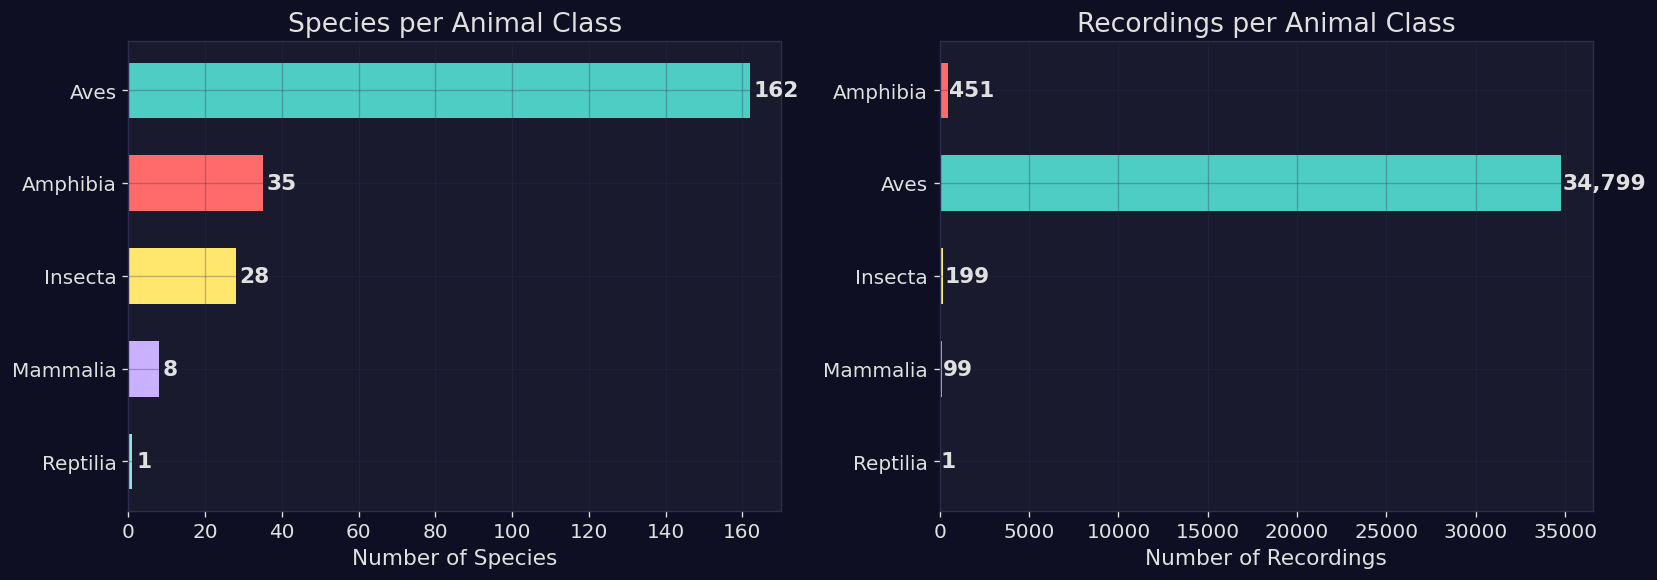

In [8]:
class_counts = taxonomy_df['class_name'].value_counts()
rec_per_class = train_df.groupby('class_name')['filename'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(class_counts.index, class_counts.values,
                     color=[CLASS_COLORS.get(c, COLORS['primary']) for c in class_counts.index],
                     edgecolor='none', height=0.6)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=13, fontweight='bold', color=COLORS['text'])
axes[0].set_xlabel("Number of Species")
axes[0].set_title("Species per Animal Class")
axes[0].invert_yaxis()

bars2 = axes[1].barh(rec_per_class.index, rec_per_class.values,
                      color=[CLASS_COLORS.get(c, COLORS['primary']) for c in rec_per_class.index],
                      edgecolor='none', height=0.6)
for bar, val in zip(bars2, rec_per_class.values):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va='center', fontsize=13, fontweight='bold', color=COLORS['text'])
axes[1].set_xlabel("Number of Recordings")
axes[1].set_title("Recordings per Animal Class")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{WORK}/01_class_distribution.png")
plt.show()

### 3.2 Species Recording Counts

The distribution across species matters a lot. A flat distribution means balanced training -- a long tail means the model may struggle with rare species. The gap between the most-recorded and least-recorded species tells us how much class balancing we might need.

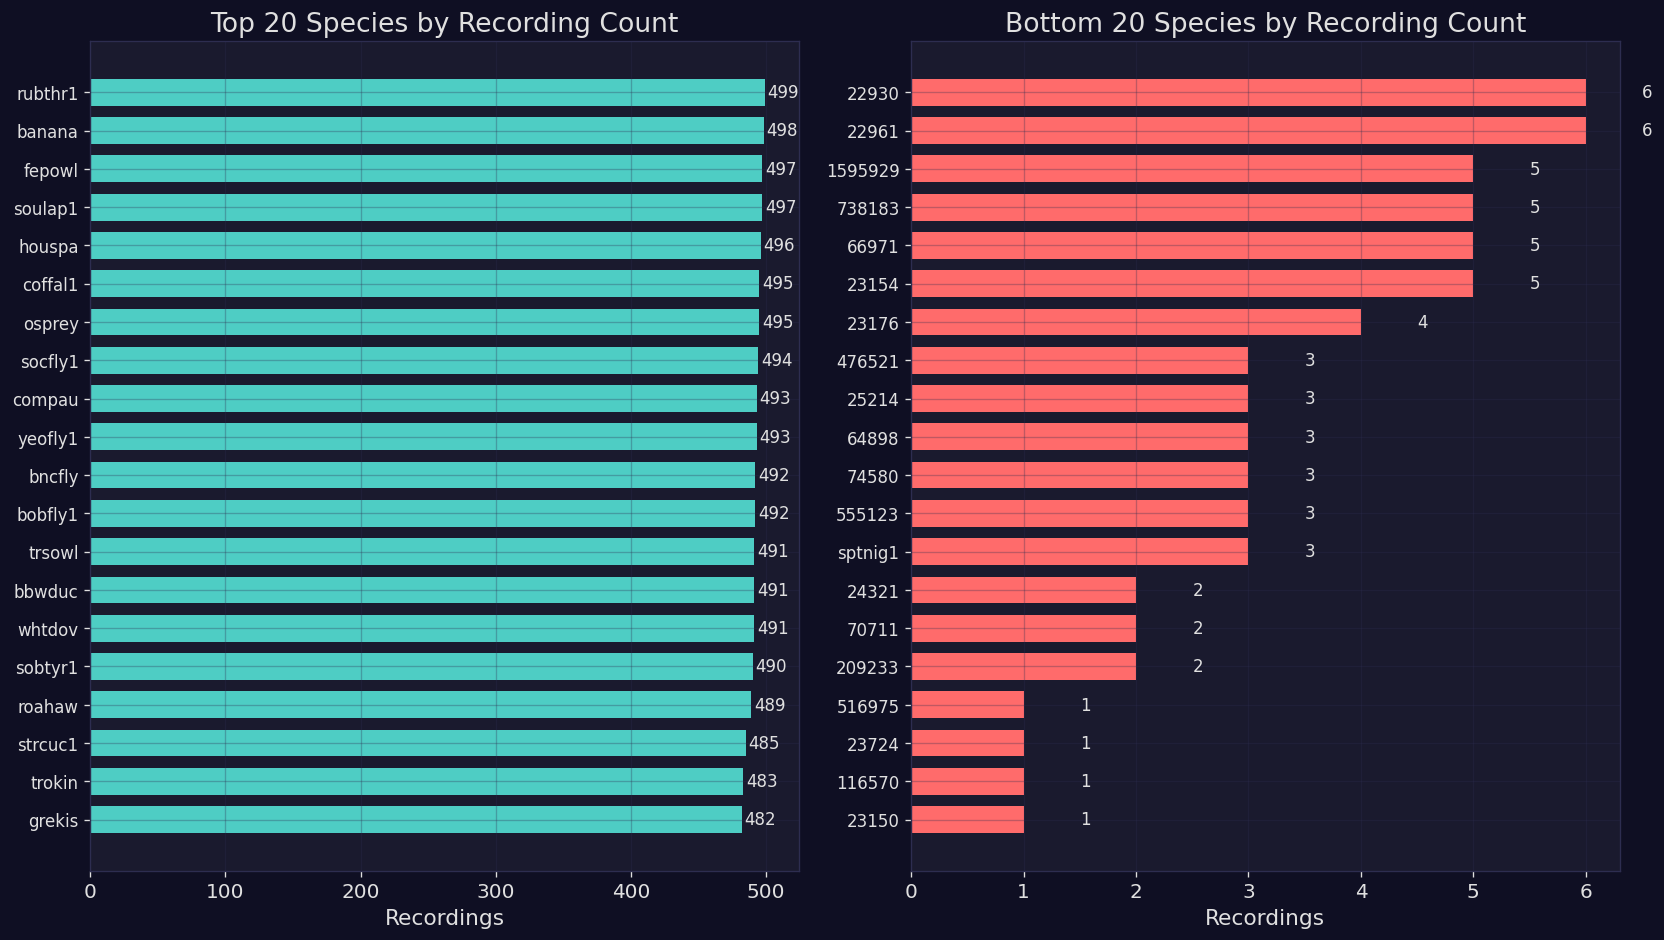

Max recordings per species: 499 (rubthr1)
Min recordings per species: 1 (516975)
Median: 125 | Mean: 173


In [9]:
species_counts = train_df['primary_label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top20 = species_counts.head(20)
axes[0].barh(range(len(top20)), top20.values[::-1], color=COLORS['primary'], edgecolor='none', height=0.7)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index[::-1], fontsize=10)
for i, val in enumerate(top20.values[::-1]):
    axes[0].text(val + 2, i, str(val), va='center', fontsize=10, color=COLORS['text'])
axes[0].set_xlabel("Recordings")
axes[0].set_title("Top 20 Species by Recording Count")

bot20 = species_counts.tail(20)
axes[1].barh(range(len(bot20)), bot20.values[::-1], color=COLORS['secondary'], edgecolor='none', height=0.7)
axes[1].set_yticks(range(len(bot20)))
axes[1].set_yticklabels(bot20.index[::-1], fontsize=10)
for i, val in enumerate(bot20.values[::-1]):
    axes[1].text(val + 0.5, i, str(val), va='center', fontsize=10, color=COLORS['text'])
axes[1].set_xlabel("Recordings")
axes[1].set_title("Bottom 20 Species by Recording Count")

plt.tight_layout()
plt.savefig(f"{WORK}/02_species_counts.png")
plt.show()

print(f"Max recordings per species: {species_counts.max()} ({species_counts.idxmax()})")
print(f"Min recordings per species: {species_counts.min()} ({species_counts.idxmin()})")
print(f"Median: {species_counts.median():.0f} | Mean: {species_counts.mean():.0f}")

### 3.3 Recording Quality and Source

Xeno-canto provides user ratings from 1 to 5. iNaturalist does not -- those show up as 0. Roughly a third of our data has no quality signal at all. The rating distribution among scored recordings leans strongly toward 4.0 and 5.0, which is good -- most submissions are carefully curated by enthusiastic contributors.

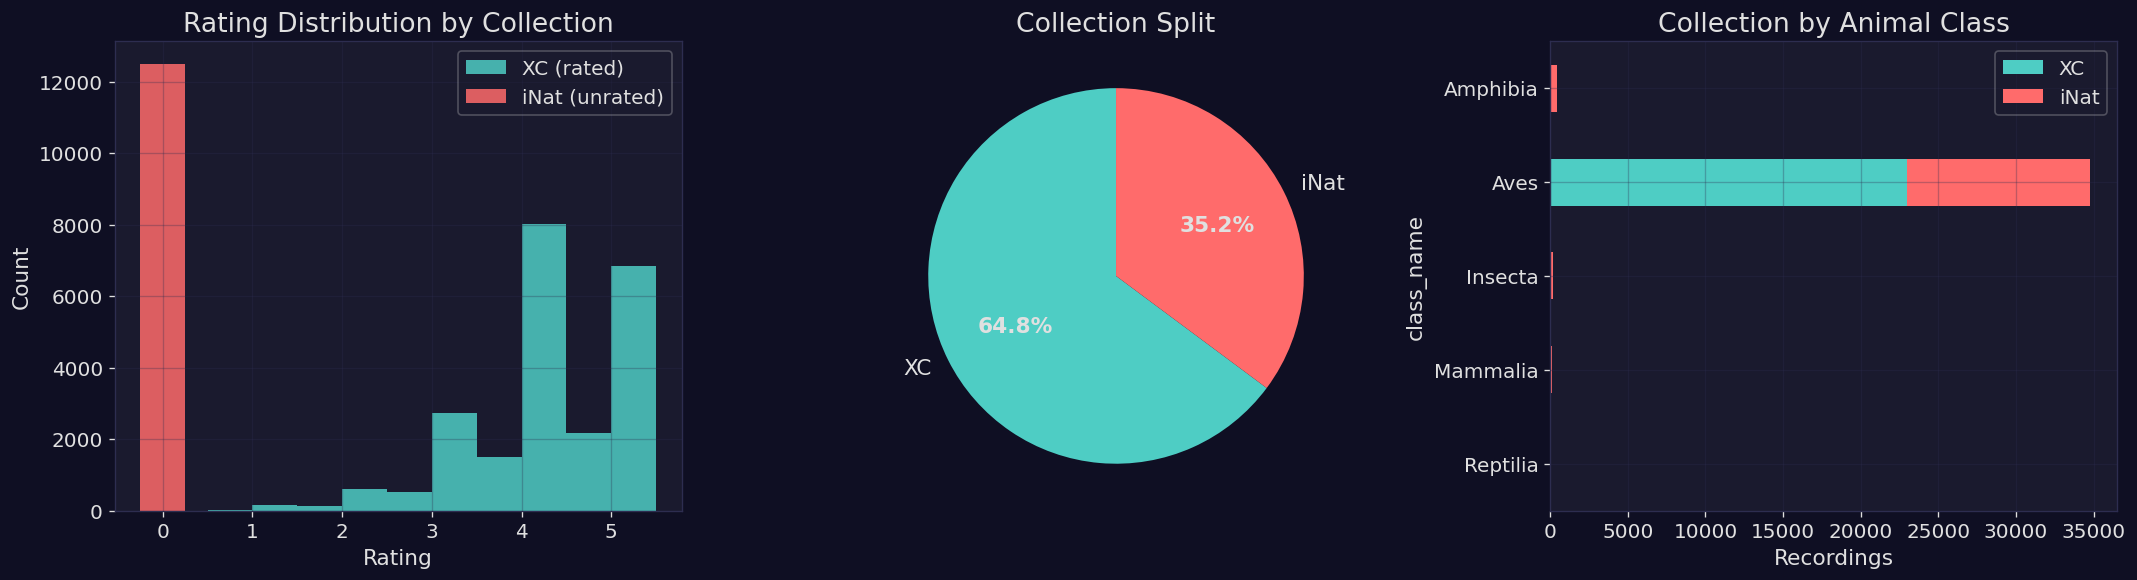

Unrated recordings (rating=0): 12849 (36.1%)
High quality (rating >= 4): 17048


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xc = train_df[train_df['collection'] == 'XC']['rating']
inat = train_df[train_df['collection'] == 'iNat']['rating']

axes[0].hist(xc[xc > 0], bins=np.arange(0.5, 5.6, 0.5), color=COLORS['primary'],
             alpha=0.85, edgecolor='none', label='XC (rated)')
axes[0].hist(inat, bins=np.arange(-0.25, 0.75, 0.5), color=COLORS['secondary'],
             alpha=0.85, edgecolor='none', label='iNat (unrated)')
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution by Collection")
axes[0].legend(framealpha=0.3)

coll_counts = train_df['collection'].value_counts()
wedges, texts, autotexts = axes[1].pie(
    coll_counts.values, labels=coll_counts.index,
    colors=[COLORS['primary'], COLORS['secondary']],
    autopct='%1.1f%%', startangle=90,
    textprops={'color': COLORS['text'], 'fontsize': 13})
for t in autotexts:
    t.set_fontweight('bold')
axes[1].set_title("Collection Split")

class_coll = train_df.groupby(['class_name', 'collection']).size().unstack(fill_value=0)
class_coll.plot(kind='barh', stacked=True, ax=axes[2],
                color=[COLORS['primary'], COLORS['secondary']], edgecolor='none')
axes[2].set_xlabel("Recordings")
axes[2].set_title("Collection by Animal Class")
axes[2].legend(framealpha=0.3)
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{WORK}/03_rating_collection.png")
plt.show()

print(f"Unrated recordings (rating=0): {(train_df['rating']==0).sum()} ({(train_df['rating']==0).mean()*100:.1f}%)")
print(f"High quality (rating >= 4): {(train_df['rating']>=4).sum()}")

### 3.4 Geographic Distribution

Training recordings come from around the world -- Xeno-canto is a global platform and many of these species have ranges far beyond the Pantanal. But the test soundscapes all come from recording sites within the Pantanal region. This geographic domain gap between training and test data is something to keep in mind: species may sound different in different parts of their range.

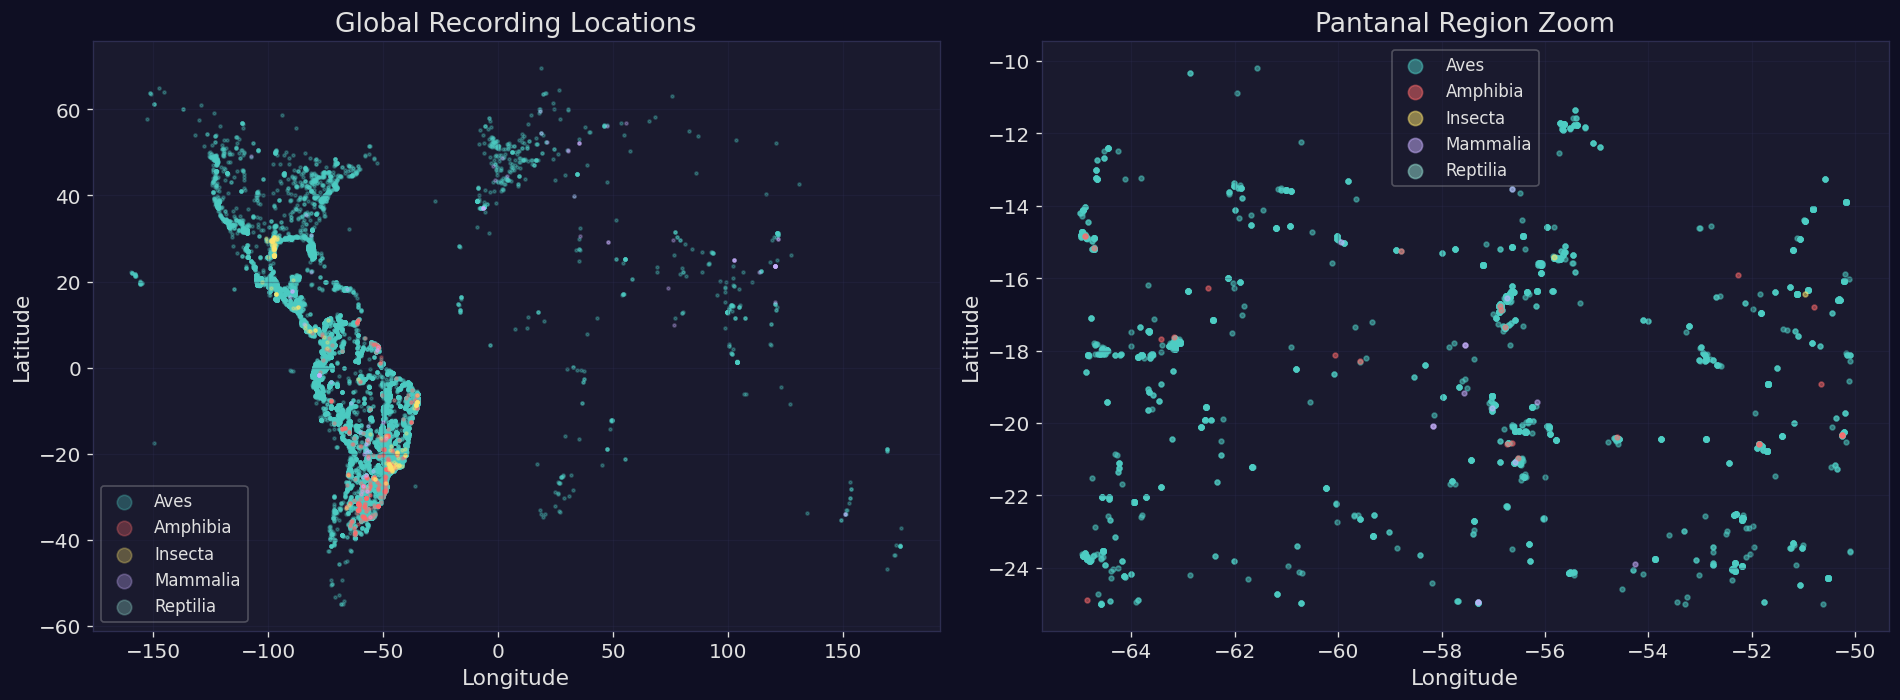

Recordings within Pantanal region: 3902 (11.0%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls, color in CLASS_COLORS.items():
    mask = train_df['class_name'] == cls
    axes[0].scatter(train_df.loc[mask, 'longitude'], train_df.loc[mask, 'latitude'],
                    c=color, s=3, alpha=0.3, label=cls, rasterized=True)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Global Recording Locations")
axes[0].legend(markerscale=5, framealpha=0.3, fontsize=10)

pantanal_mask = ((train_df['latitude'].between(-25, -10)) &
                 (train_df['longitude'].between(-65, -50)))
for cls, color in CLASS_COLORS.items():
    mask = pantanal_mask & (train_df['class_name'] == cls)
    axes[1].scatter(train_df.loc[mask, 'longitude'], train_df.loc[mask, 'latitude'],
                    c=color, s=8, alpha=0.5, label=cls, rasterized=True)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Pantanal Region Zoom")
axes[1].legend(markerscale=3, framealpha=0.3, fontsize=10)

plt.tight_layout()
plt.savefig(f"{WORK}/04_geographic.png")
plt.show()

print(f"Recordings within Pantanal region: {pantanal_mask.sum()} ({pantanal_mask.mean()*100:.1f}%)")

### 3.5 Recording Duration

Shorter recordings mean fewer training samples per file. Some files barely exceed the 5-second prediction window. Understanding the duration distribution helps decide padding and cropping strategies.

Reading durations:   0%|          | 0/2000 [00:00<?, ?it/s]

Successfully read 2000 / 2000 files


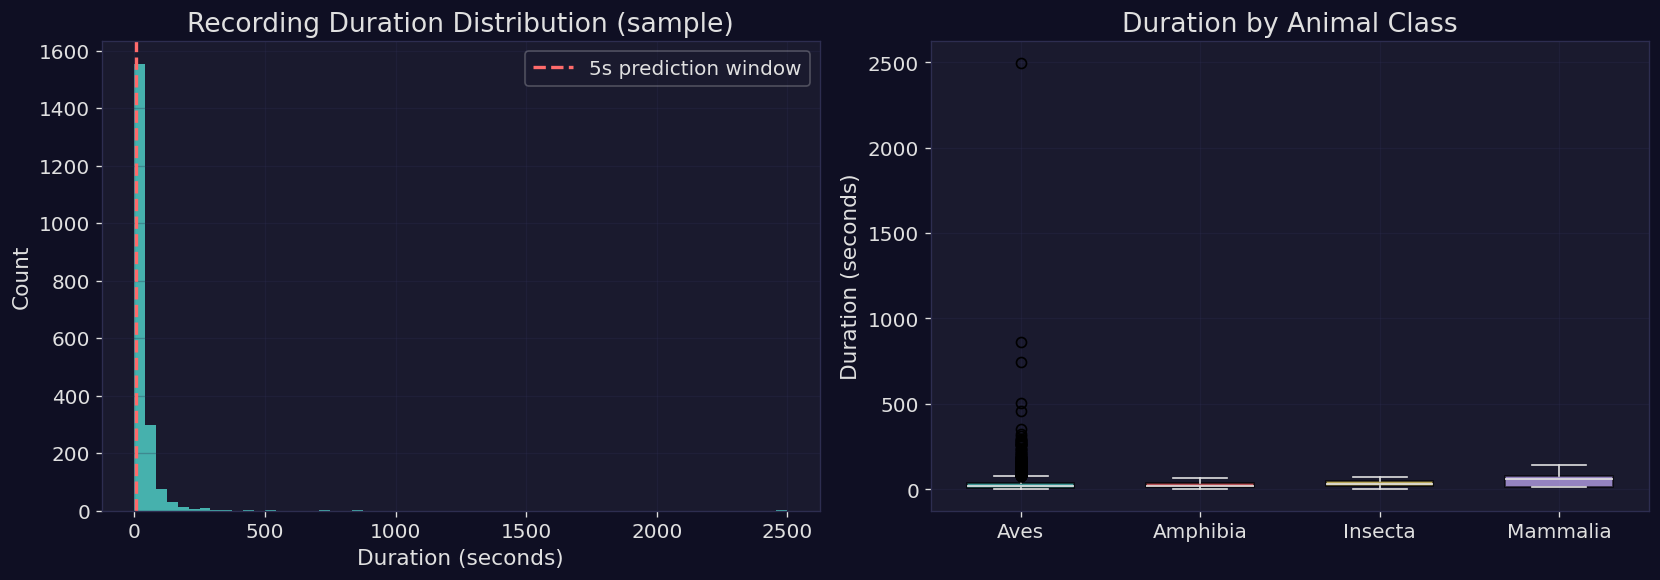

Mean duration: 34.7s | Median: 20.8s
Under 5 seconds: 168 (8.4%)


In [12]:
sample_files = train_df.sample(min(2000, len(train_df)), random_state=SEED)
durations = []
for _, row in tqdm(sample_files.iterrows(), total=len(sample_files), desc="Reading durations"):
    fpath = f"{ROOT}/train_audio/{row['filename']}"
    try:
        dur = librosa.get_duration(filename=fpath)
        durations.append({'primary_label': row['primary_label'],
                          'class_name': row['class_name'],
                          'duration': dur})
    except:
        pass

dur_df = pd.DataFrame(durations)
print(f"Successfully read {len(dur_df)} / {len(sample_files)} files")

if len(dur_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(dur_df['duration'], bins=60, color=COLORS['primary'], edgecolor='none', alpha=0.85)
    axes[0].axvline(5, color=COLORS['secondary'], linestyle='--', linewidth=2, label='5s prediction window')
    axes[0].set_xlabel("Duration (seconds)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Recording Duration Distribution (sample)")
    axes[0].legend(framealpha=0.3)

    class_order = ['Aves', 'Amphibia', 'Insecta', 'Mammalia', 'Reptilia']
    plot_data = [dur_df[dur_df['class_name'] == c]['duration'].values for c in class_order if c in dur_df['class_name'].values]
    plot_labels = [c for c in class_order if c in dur_df['class_name'].values]
    bp = axes[1].boxplot(plot_data, labels=plot_labels, patch_artist=True, widths=0.6)
    for patch, label in zip(bp['boxes'], plot_labels):
        patch.set_facecolor(CLASS_COLORS.get(label, COLORS['primary']))
        patch.set_alpha(0.7)
    for element in ['whiskers', 'caps', 'medians']:
        for line in bp[element]:
            line.set_color(COLORS['text'])
    axes[1].set_ylabel("Duration (seconds)")
    axes[1].set_title("Duration by Animal Class")

    plt.tight_layout()
    plt.savefig(f"{WORK}/05_duration.png")
    plt.show()

    print(f"Mean duration: {dur_df['duration'].mean():.1f}s | Median: {dur_df['duration'].median():.1f}s")
    print(f"Under 5 seconds: {(dur_df['duration'] < 5).sum()} ({(dur_df['duration'] < 5).mean()*100:.1f}%)")
else:
    print("Could not read any audio file durations, skipping plot")

### 3.6 Species Overlap: train_audio vs. train_soundscapes

Some species appear only in the labeled soundscapes. If we train solely on `train_audio`, we will miss those entirely. This is one of the most important structural findings in the data -- our training pipeline needs to incorporate soundscape segments.

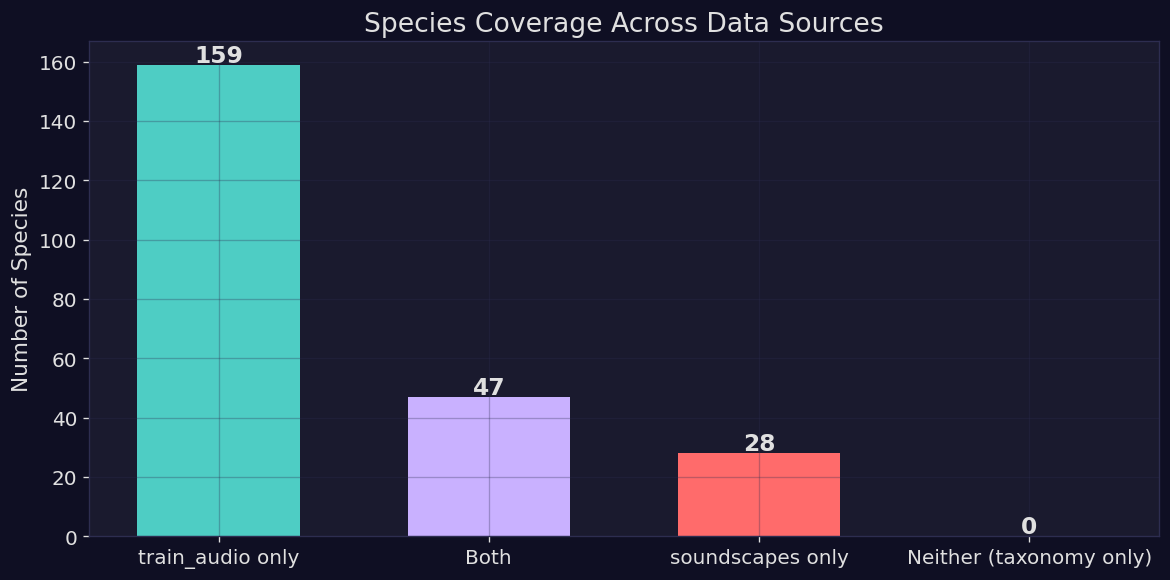

Species in train_audio: 206
Species in soundscape labels: 75
Species in taxonomy (target): 234
Soundscape-only species: {'47158son12', '47158son24', '47158son23', '47158son04', '47158son02', '1491113', '47158son22', '47158son17', '47158son08', '517063', '47158son15', '47158son10', '47158son19', '47158son05', '47158son07', '47158son03', '47158son11', '47158son20', '47158son13', '47158son06', '47158son14', '25073', '47158son01', '47158son25', '47158son18', '47158son09', '47158son21', '47158son16'}


In [13]:
train_audio_species = set(train_df['primary_label'].unique())
taxonomy_species = set(taxonomy_df['primary_label'].unique())

sc_species = set()
for labels_str in soundscape_labels['primary_label'].dropna():
    for sp in str(labels_str).split(';'):
        sp = sp.strip()
        if sp:
            sc_species.add(sp)

only_audio = train_audio_species - sc_species
only_sc = sc_species - train_audio_species
both = train_audio_species & sc_species
neither = taxonomy_species - train_audio_species - sc_species

fig, ax = plt.subplots(figsize=(10, 5))

categories = ['train_audio only', 'Both', 'soundscapes only', 'Neither (taxonomy only)']
counts = [len(only_audio), len(both), len(only_sc), len(neither)]
bar_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary'], COLORS['yellow']]

bars = ax.bar(categories, counts, color=bar_colors, edgecolor='none', width=0.6)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=14, fontweight='bold', color=COLORS['text'])
ax.set_ylabel("Number of Species")
ax.set_title("Species Coverage Across Data Sources")

plt.tight_layout()
plt.savefig(f"{WORK}/06_species_overlap.png")
plt.show()

print(f"Species in train_audio: {len(train_audio_species)}")
print(f"Species in soundscape labels: {len(sc_species)}")
print(f"Species in taxonomy (target): {len(taxonomy_species)}")
print(f"Soundscape-only species: {only_sc}")

### 3.7 Secondary Labels

Many recordings capture more than one species calling at the same time. The secondary labels tell us what else is in the background. These can serve as weak multi-label supervision during training -- or at least teach us which species tend to co-occur.

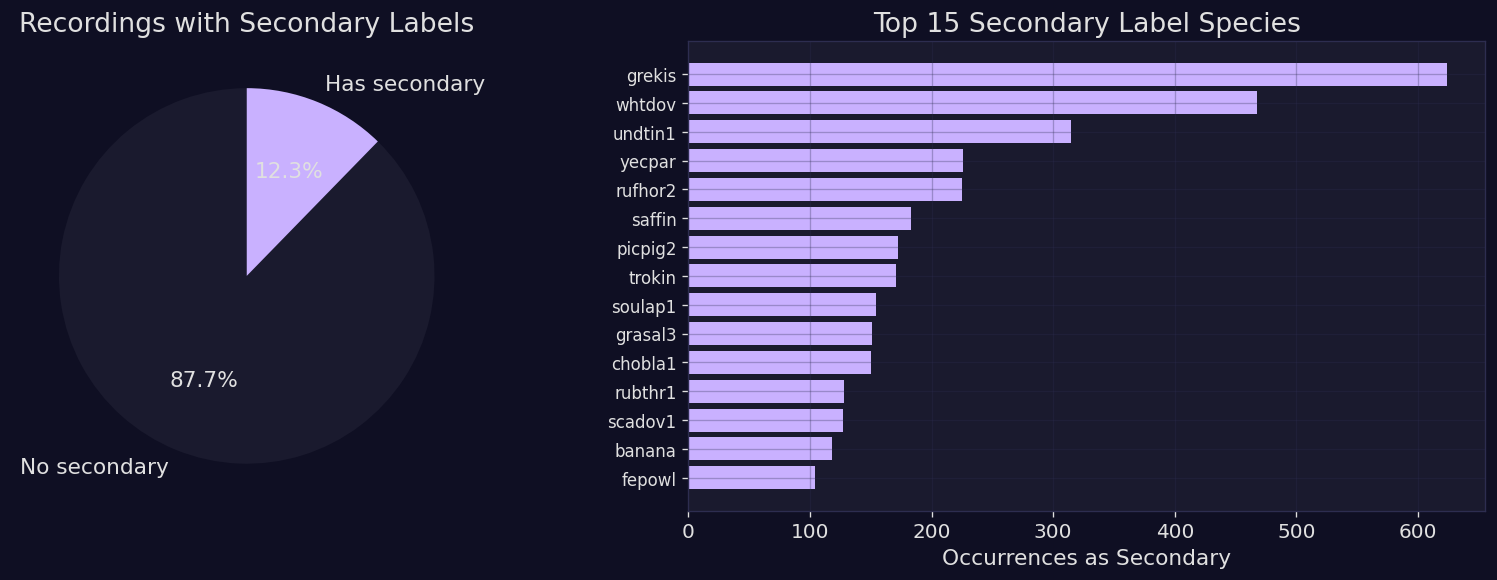

Recordings with secondary labels: 4372
Unique secondary species: 161


In [14]:
train_df['has_secondary'] = train_df['secondary_labels'].apply(
    lambda x: isinstance(x, str) and x not in ['[]', ''] and pd.notna(x))

def parse_secondary(val):
    if not isinstance(val, str) or val in ['[]', '']:
        return []
    val = val.strip("[]").replace("'", "").replace('"', '')
    return [s.strip() for s in val.split(',') if s.strip()]

all_secondary = []
for val in train_df['secondary_labels']:
    all_secondary.extend(parse_secondary(val))
sec_counter = Counter(all_secondary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

has_sec = train_df['has_secondary'].value_counts()
axes[0].pie(has_sec.values, labels=['No secondary', 'Has secondary'],
            colors=[COLORS['panel'], COLORS['accent']],
            autopct='%1.1f%%', startangle=90,
            textprops={'color': COLORS['text'], 'fontsize': 13})
axes[0].set_title("Recordings with Secondary Labels")

top_sec = pd.Series(dict(sec_counter.most_common(15)))
axes[1].barh(range(len(top_sec)), top_sec.values[::-1], color=COLORS['accent'], edgecolor='none')
axes[1].set_yticks(range(len(top_sec)))
axes[1].set_yticklabels(top_sec.index[::-1], fontsize=10)
axes[1].set_xlabel("Occurrences as Secondary")
axes[1].set_title("Top 15 Secondary Label Species")

plt.tight_layout()
plt.savefig(f"{WORK}/07_secondary_labels.png")
plt.show()

print(f"Recordings with secondary labels: {train_df['has_secondary'].sum()}")
print(f"Unique secondary species: {len(sec_counter)}")

<a id="4"></a>
## 4. Audio Visualizations

Each animal class has a distinct acoustic fingerprint. Birds tend to produce sharp, high-frequency calls. Frogs occupy the low-frequency range with rhythmic repetition. Insects generate broadband, continuous noise. Mammals often overlap with birds but with different temporal patterns. The lone reptile class is the wild card.

Below, we pick one representative species from each class and compare their waveforms and mel spectrograms side-by-side.

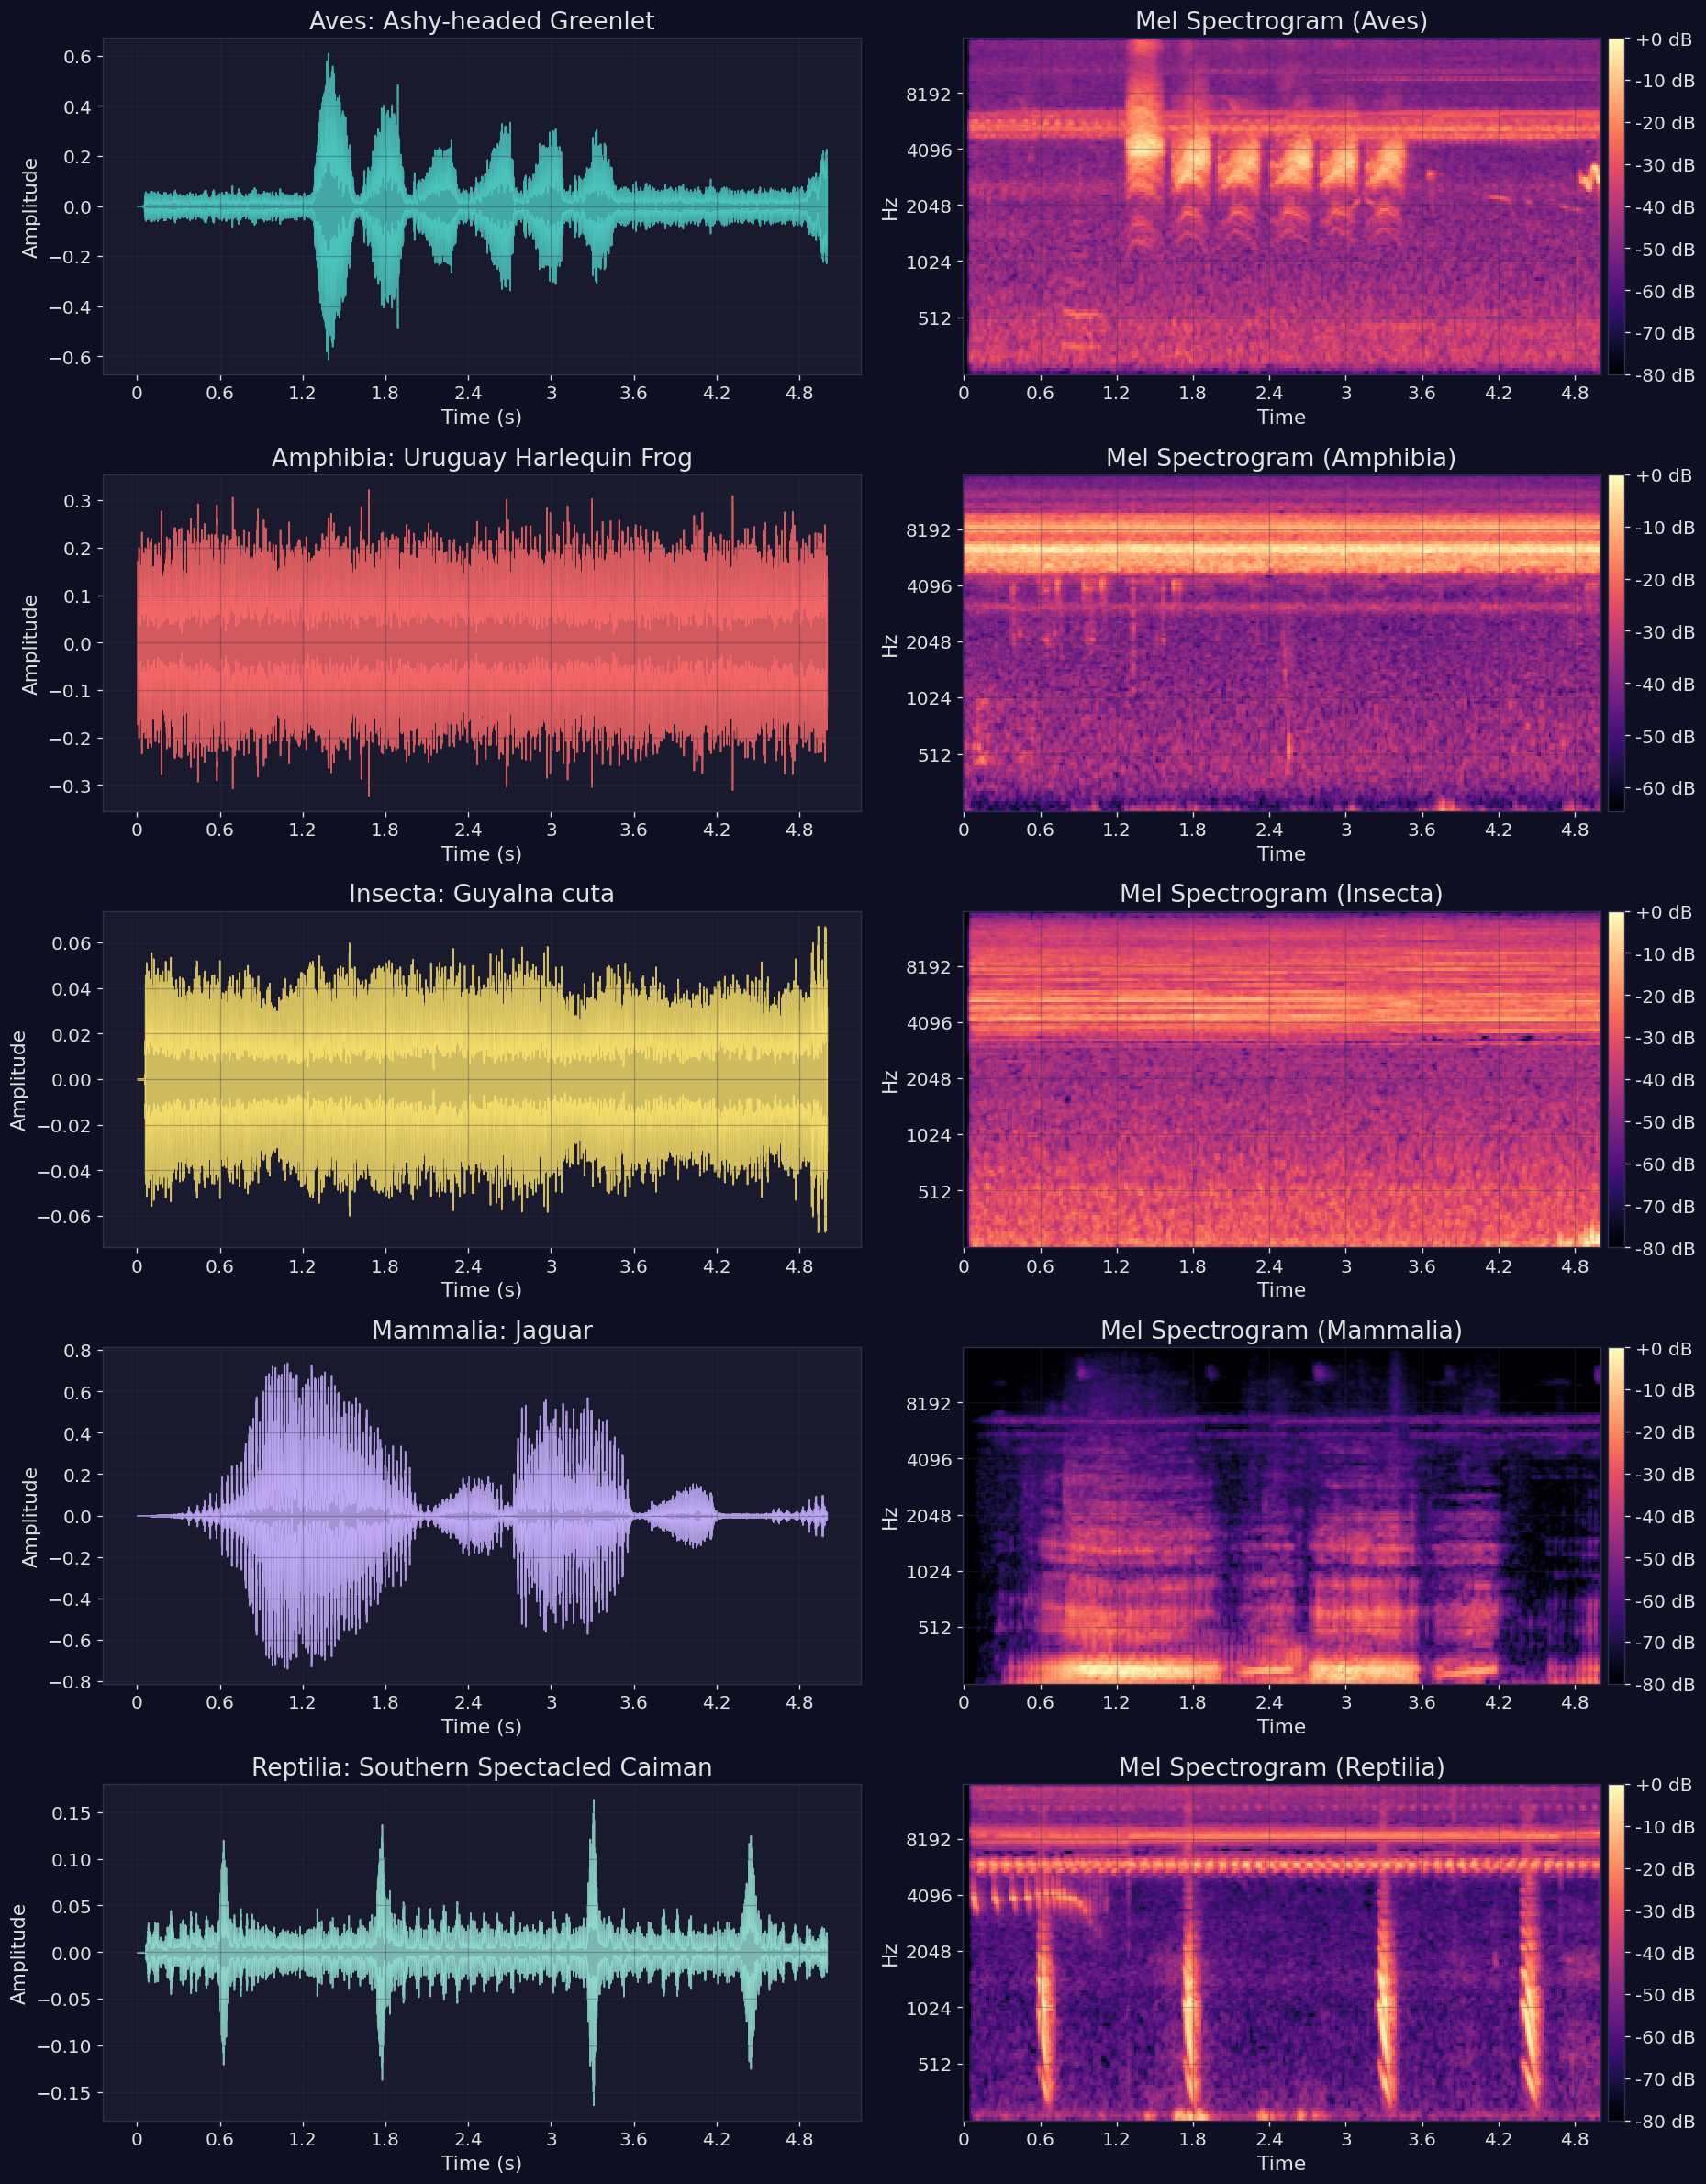

In [15]:
classes_to_show = ['Aves', 'Amphibia', 'Insecta', 'Mammalia', 'Reptilia']
available_classes = [c for c in classes_to_show if c in train_df['class_name'].values]

fig, axes = plt.subplots(len(available_classes), 2, figsize=(16, 4 * len(available_classes)))
if len(available_classes) == 1:
    axes = axes.reshape(1, -1)

for idx, cls in enumerate(available_classes):
    subset = train_df[train_df['class_name'] == cls]
    if subset.empty:
        continue

    high_rated = subset[subset['rating'] >= 3.0]
    sample_row = high_rated.iloc[0] if len(high_rated) > 0 else subset.iloc[0]

    fpath = f"{ROOT}/train_audio/{sample_row['filename']}"
    y, sr_lib = librosa.load(fpath, sr=SR, duration=DURATION)

    if len(y) < SR * DURATION:
        y = np.pad(y, (0, SR * DURATION - len(y)))

    color = CLASS_COLORS.get(cls, COLORS['primary'])
    librosa.display.waveshow(y, sr=SR, ax=axes[idx, 0], color=color, alpha=0.8)
    axes[idx, 0].set_title(f"{cls}: {sample_row.get('common_name', sample_row['primary_label'])}")
    axes[idx, 0].set_xlabel("Time (s)")
    axes[idx, 0].set_ylabel("Amplitude")

    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                                         hop_length=HOP_LENGTH, fmin=F_MIN, fmax=F_MAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH,
                                    x_axis='time', y_axis='mel', ax=axes[idx, 1],
                                    cmap='magma', fmin=F_MIN, fmax=F_MAX)
    axes[idx, 1].set_title(f"Mel Spectrogram ({cls})")
    fig.colorbar(img, ax=axes[idx, 1], format='%+2.0f dB', pad=0.01)

plt.tight_layout()
plt.savefig(f"{WORK}/08_audio_comparison.png")
plt.show()

<a id="5"></a>
## 5. Labeled Soundscapes Deep-Dive

This is the first year BirdCLEF provides expert-annotated soundscape segments. These are vastly more valuable than the isolated single-species recordings in `train_audio` because they mirror what the model sees at test time: multi-species, noisy, continuous recordings from the same PAM network.

We use them both for validation and, potentially, as additional training data.

In [16]:
print(f"Labeled segments: {len(soundscape_labels)}")
print(f"Unique soundscape files: {soundscape_labels['filename'].nunique()}")
print(f"Columns: {soundscape_labels.columns.tolist()}")
soundscape_labels.head(5)

Labeled segments: 1478
Unique soundscape files: 66
Columns: ['filename', 'start', 'end', 'primary_label']


,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,0.0,5.0,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,5.0,10.0,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,10.0,15.0,22961;23158;24321;517063;65380
3,BC2026_Train_0039_S22_20211231_201500.ogg,15.0,20.0,22961;23158;24321;517063;65380
4,BC2026_Train_0039_S22_20211231_201500.ogg,20.0,25.0,22961;23158;24321;517063;65380


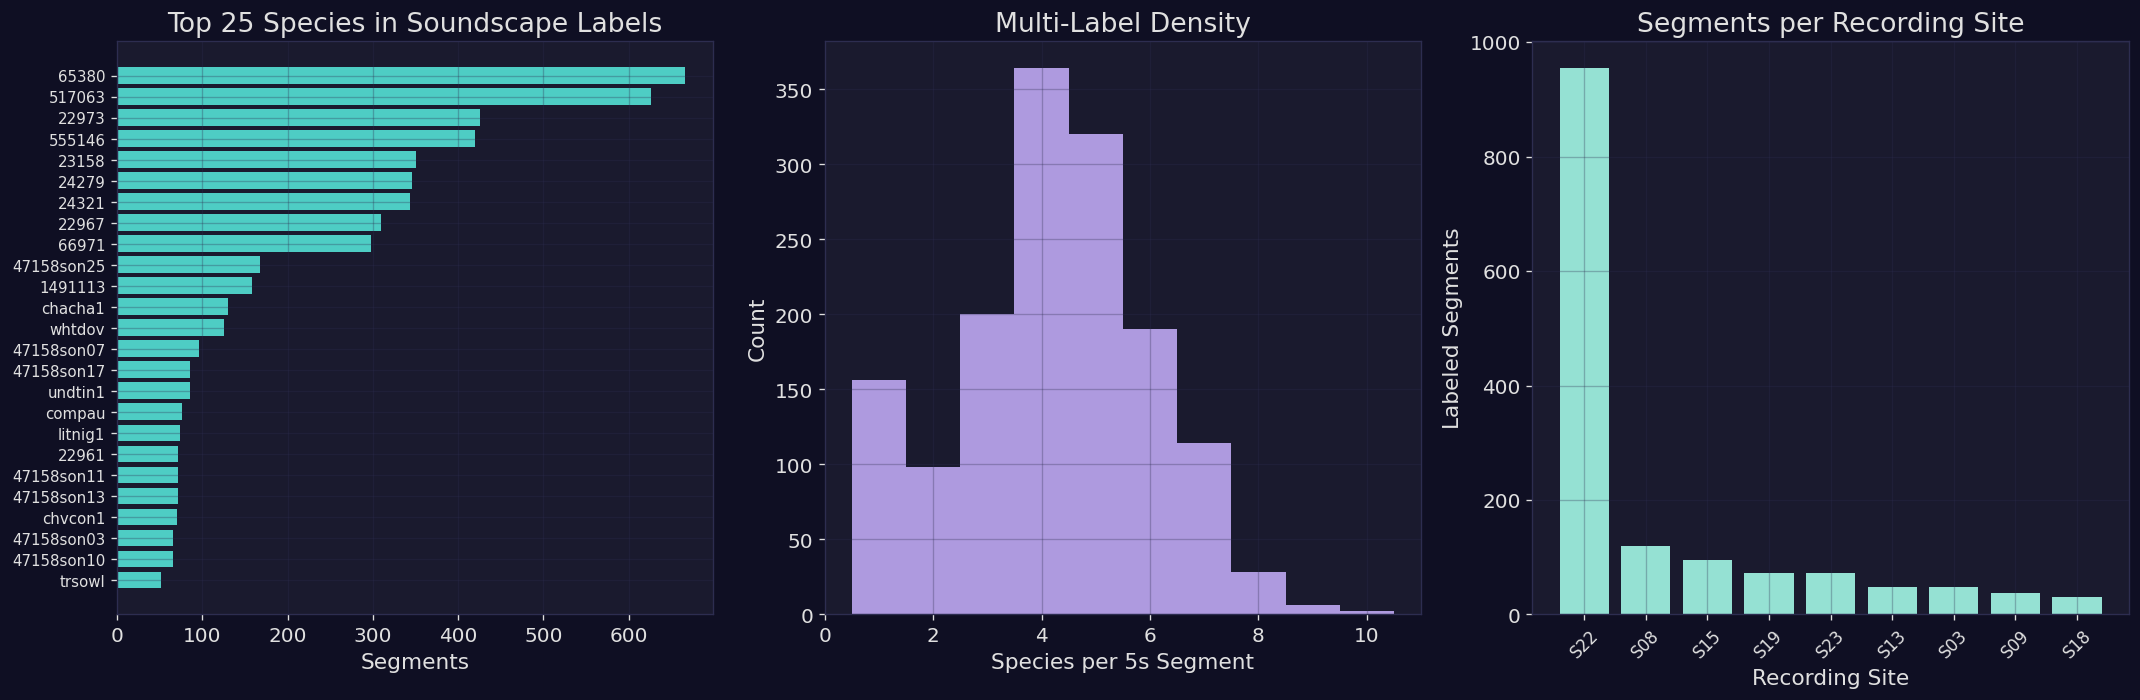

Unique species in soundscape labels: 75
Mean species per segment: 4.22
Max species per segment: 10


In [17]:
sc_species_list = []
sc_label_counts = []
for _, row in soundscape_labels.iterrows():
    species = [s.strip() for s in str(row['primary_label']).split(';') if s.strip()]
    sc_species_list.extend(species)
    sc_label_counts.append(len(species))

sc_species_counter = Counter(sc_species_list)
soundscape_labels['n_species'] = sc_label_counts

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_sc = pd.Series(dict(sc_species_counter.most_common(25)))
axes[0].barh(range(len(top_sc)), top_sc.values[::-1], color=COLORS['primary'], edgecolor='none')
axes[0].set_yticks(range(len(top_sc)))
axes[0].set_yticklabels(top_sc.index[::-1], fontsize=9)
axes[0].set_xlabel("Segments")
axes[0].set_title("Top 25 Species in Soundscape Labels")

axes[1].hist(soundscape_labels['n_species'], bins=range(1, soundscape_labels['n_species'].max() + 2),
             color=COLORS['accent'], edgecolor='none', alpha=0.85, align='left')
axes[1].set_xlabel("Species per 5s Segment")
axes[1].set_ylabel("Count")
axes[1].set_title("Multi-Label Density")

sc_sites = soundscape_labels['filename'].apply(lambda x: x.split('_')[3] if len(x.split('_')) > 3 else 'unknown')
site_counts = sc_sites.value_counts()
axes[2].bar(range(len(site_counts)), site_counts.values,
            color=COLORS['mint'], edgecolor='none')
axes[2].set_xticks(range(len(site_counts)))
axes[2].set_xticklabels(site_counts.index, rotation=45, fontsize=10)
axes[2].set_xlabel("Recording Site")
axes[2].set_ylabel("Labeled Segments")
axes[2].set_title("Segments per Recording Site")

plt.tight_layout()
plt.savefig(f"{WORK}/09_soundscape_labels.png")
plt.show()

print(f"Unique species in soundscape labels: {len(sc_species_counter)}")
print(f"Mean species per segment: {np.mean(sc_label_counts):.2f}")
print(f"Max species per segment: {max(sc_label_counts)}")

### Key Takeaways from EDA

Several findings shape the modeling approach:

- The class distribution is manageable -- most species have around 100-500 recordings, but there is a tail of rarer species that need attention.
- Over a third of recordings have no quality rating. Filtering by rating helps but would discard all iNaturalist data.
- The geographic gap is real: training audio is global, test audio is local to the Pantanal. Domain adaptation matters.
- The labeled soundscapes are gold: they match the test distribution and let us build a proper local validation set.
- Some species only exist in soundscape data. The model must train on these segments or it cannot predict them at all.
- Multi-label segments are common in soundscapes -- the model must handle concurrent species.

---

      still working... will update following steps in next days -_-

<a id="6"></a>
## 6. Model Architecture and Training


<a id="7"></a>
## 7. Inference Pipeline


<a id="8"></a>
## 8. Results and Next Steps



Notebook by **MIQ** for the BirdCLEF+ 2026 competition.